In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

COUNTRIES = ['Ethiopia', 'Kenya', 'Tanzania', 'Sudan', 'Nigeria']
COLORS    = {'Ethiopia':'#E63946','Kenya':'#2A9D8F','Tanzania':'#E9C46A',
             'Sudan':'#F4A261','Nigeria':'#457B9D'}


In [2]:
frames = []
for c in COUNTRIES:
    path = f"data/{c.lower()}_clean.csv"
    df = pd.read_csv(path, parse_dates=['Date'])
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined['Month'] = combined['Date'].dt.month
combined['Year']  = combined['Date'].dt.year

print("Combined shape:", combined.shape)
print("\nRows per country:")
print(combined['Country'].value_counts())
combined.head()


Combined shape: (20540, 16)

Rows per country:
Country
Ethiopia    4108
Kenya       4108
Tanzania    4108
Sudan       4108
Nigeria     4108
Name: count, dtype: int64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


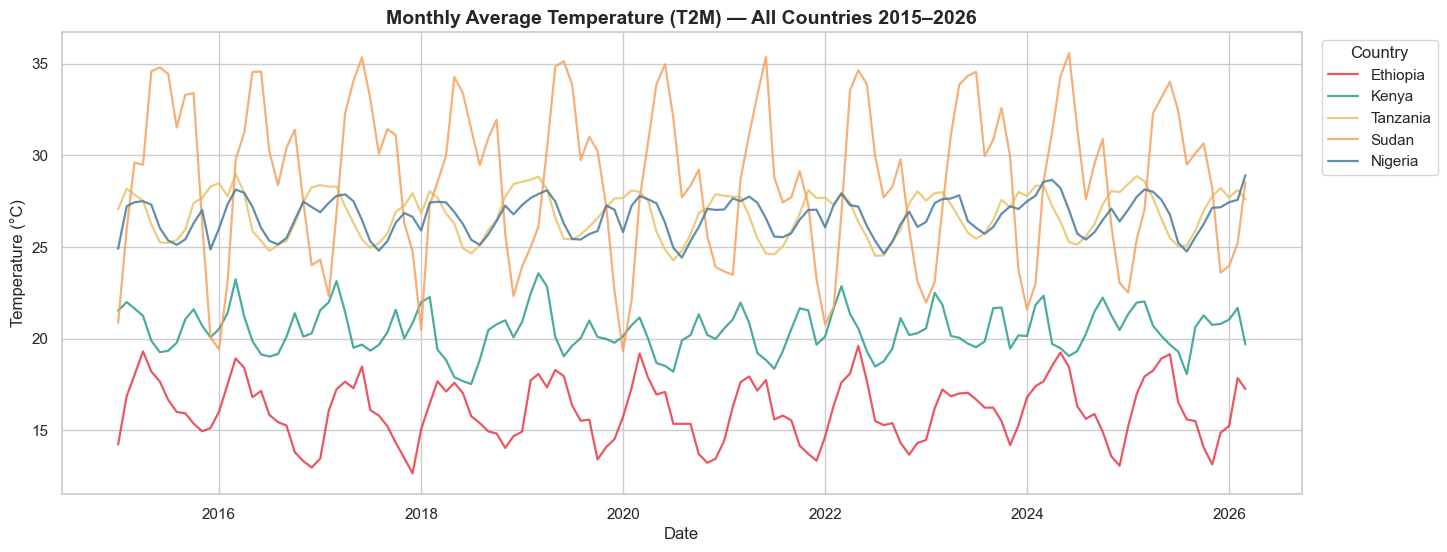

In [3]:
# Monthly average T2M per country
monthly = (combined
    .groupby(['Country','Year','Month'])['T2M']
    .mean()
    .reset_index())
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(Day=1))
monthly = monthly.sort_values('Date')

fig, ax = plt.subplots(figsize=(16, 6))
for country in COUNTRIES:
    sub = monthly[monthly['Country'] == country]
    ax.plot(sub['Date'], sub['T2M'], label=country,
            color=COLORS[country], linewidth=1.6, alpha=0.85)

ax.set_title('Monthly Average Temperature (T2M) — All Countries 2015–2026',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.show()


In [4]:
temp_summary = (combined
    .groupby('Country')['T2M']
    .agg(Mean='mean', Median='median', Std='std', Min='min', Max='max')
    .round(2)
    .sort_values('Mean', ascending=False))
print("T2M Summary Statistics by Country:")
temp_summary


T2M Summary Statistics by Country:


,Mean,Median,Std,Min,Max
Country,,,,,
Sudan,28.76,29.16,4.68,13.18,37.99
Tanzania,26.80,26.99,1.33,22.68,29.97
Nigeria,26.66,26.82,1.12,21.12,29.29
Kenya,20.43,20.36,1.44,15.26,25.40
Ethiopia,16.07,16.04,1.90,10.03,21.53


C:\Users\hp\AppData\Local\Temp\ipykernel_16292\320380607.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=COUNTRIES, patch_artist=True,


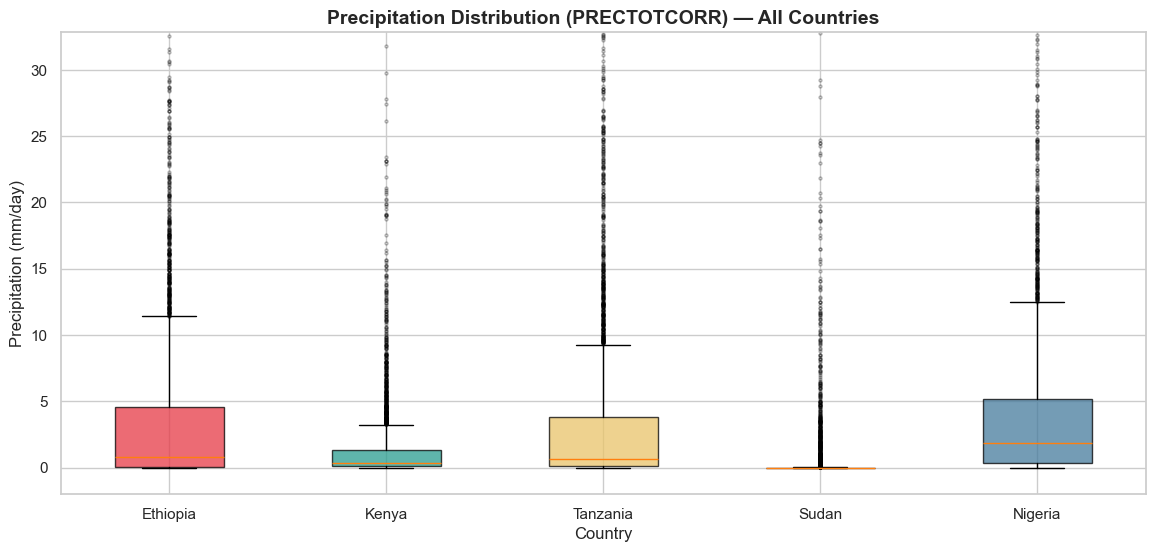

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

data_for_box = [combined[combined['Country'] == c]['PRECTOTCORR'].dropna().values
                for c in COUNTRIES]

bp = ax.boxplot(data_for_box, labels=COUNTRIES, patch_artist=True,
                showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.3))

for patch, country in zip(bp['boxes'], COUNTRIES):
    patch.set_facecolor(COLORS[country])
    patch.set_alpha(0.75)

ax.set_title('Precipitation Distribution (PRECTOTCORR) — All Countries',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_ylim(-2, combined['PRECTOTCORR'].quantile(0.99) + 5)

plt.show()


In [6]:
precip_summary = (combined
    .groupby('Country')['PRECTOTCORR']
    .agg(Mean='mean', Median='median', Std='std', Max='max')
    .round(2)
    .sort_values('Std', ascending=False))
print("PRECTOTCORR Summary Statistics by Country:")
precip_summary


PRECTOTCORR Summary Statistics by Country:


,Mean,Median,Std,Max
Country,,,,
Tanzania,3.74,0.64,8.00,122.65
Nigeria,4.21,1.84,7.27,166.10
Ethiopia,3.63,0.82,6.29,82.30
Kenya,1.47,0.38,3.18,51.65
Sudan,0.64,0.00,3.06,66.49


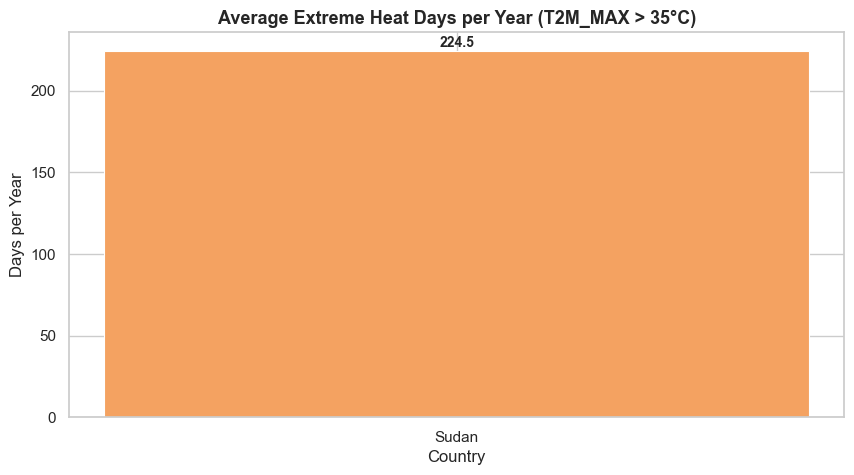

  Country  HeatDays
0   Sudan     224.5


In [7]:
# ── 5a. Extreme Heat Days: T2M_MAX > 35°C ──
heat_days = (combined[combined['T2M_MAX'] > 35]
    .groupby(['Country','Year'])
    .size()
    .reset_index(name='HeatDays'))

heat_avg = heat_days.groupby('Country')['HeatDays'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(heat_avg['Country'], heat_avg['HeatDays'],
              color=[COLORS[c] for c in heat_avg['Country']], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, heat_avg['HeatDays']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Extreme Heat Days per Year (T2M_MAX > 35°C)', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Days per Year')
plt.show()
print(heat_avg)



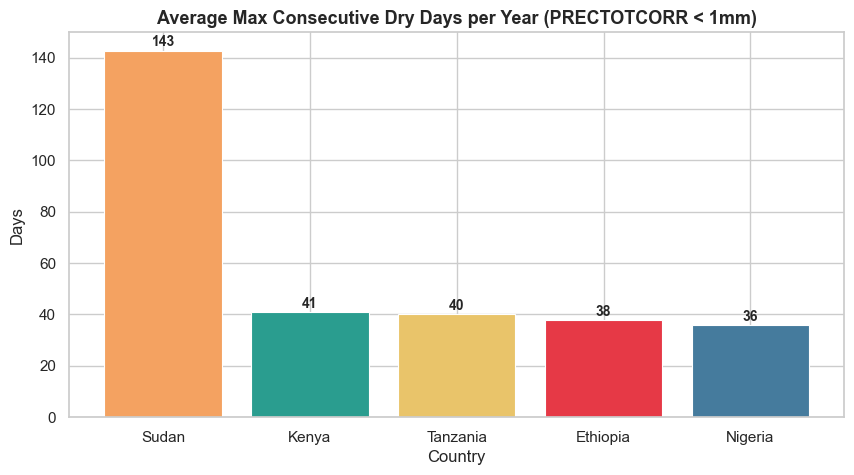

    Country  MaxConsecDryDays
0     Sudan        142.750000
1     Kenya         41.083333
2  Tanzania         40.250000
3  Ethiopia         37.916667
4   Nigeria         35.833333


In [8]:
# ── 5b. Consecutive Dry Days: PRECTOTCORR < 1mm ──
def max_consecutive_dry(series):
    dry = (series < 1).astype(int)
    max_run = 0
    run = 0
    for v in dry:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

dry_days = (combined
    .groupby(['Country','Year'])['PRECTOTCORR']
    .apply(max_consecutive_dry)
    .reset_index(name='MaxConsecDryDays'))

dry_avg = dry_days.groupby('Country')['MaxConsecDryDays'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dry_avg['Country'], dry_avg['MaxConsecDryDays'],
              color=[COLORS[c] for c in dry_avg['Country']], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, dry_avg['MaxConsecDryDays']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Max Consecutive Dry Days per Year (PRECTOTCORR < 1mm)', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Days')
plt.show()
print(dry_avg)


In [9]:
# Kruskal-Wallis test (non-parametric, no normality assumption needed)
groups = [combined[combined['Country'] == c]['T2M'].dropna().values for c in COUNTRIES]

stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis Test on T2M across all 5 countries")
print(f"{'='*50}")
print(f"H-statistic : {stat:.4f}")
print(f"p-value     : {p_value:.2e}")
print()
if p_value < 0.05:
    print("Result: SIGNIFICANT — temperature distributions differ meaningfully across countries (p < 0.05).")
    print("This confirms that country-level climate profiles are statistically distinct,")
    print("validating the use of country-specific vulnerability rankings.")
else:
    print("Result: NOT significant at p < 0.05.")


Kruskal-Wallis Test on T2M across all 5 countries
H-statistic : 15392.9922
p-value     : 0.00e+00

Result: SIGNIFICANT — temperature distributions differ meaningfully across countries (p < 0.05).
This confirms that country-level climate profiles are statistically distinct,
validating the use of country-specific vulnerability rankings.


In [10]:
# Build vulnerability score from 3 normalised metrics
# 1. Mean T2M (higher = more heat stress)
# 2. Precipitation Std (higher = more instability)
# 3. Avg extreme heat days (higher = more acute stress)

def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

scores = pd.DataFrame({'Country': COUNTRIES})

scores = scores.merge(
    combined.groupby('Country')['T2M'].mean().reset_index(name='MeanT2M'), on='Country')
scores = scores.merge(
    combined.groupby('Country')['PRECTOTCORR'].std().reset_index(name='PrecipStd'), on='Country')
scores = scores.merge(
    heat_avg.rename(columns={'HeatDays':'HeatDays'}), on='Country')
scores = scores.merge(
    dry_avg.rename(columns={'MaxConsecDryDays':'DryDays'}), on='Country')

scores['Score_Temp']   = normalise(scores['MeanT2M'])
scores['Score_Precip'] = normalise(scores['PrecipStd'])
scores['Score_Heat']   = normalise(scores['HeatDays'])
scores['Score_Dry']    = normalise(scores['DryDays'])

# Equal weights
scores['VulnerabilityScore'] = (
    scores['Score_Temp'] * 0.30 +
    scores['Score_Precip'] * 0.25 +
    scores['Score_Heat'] * 0.25 +
    scores['Score_Dry'] * 0.20
).round(3)

ranking = scores[['Country','MeanT2M','PrecipStd','HeatDays','DryDays','VulnerabilityScore']]    .sort_values('VulnerabilityScore', ascending=False)    .reset_index(drop=True)
ranking.index += 1
ranking.columns = ['Country','Mean T2M (°C)','Precip Std (mm)','Heat Days/yr','Max Dry Days/yr','Vulnerability Score']

print("Climate Vulnerability Ranking (1 = Most Vulnerable)")
ranking


Climate Vulnerability Ranking (1 = Most Vulnerable)


,Country,Mean T2M (°C),Precip Std (mm),Heat Days/yr,Max Dry Days/yr,Vulnerability Score
1,Sudan,28.759007,3.057672,224.5,142.75,NaN


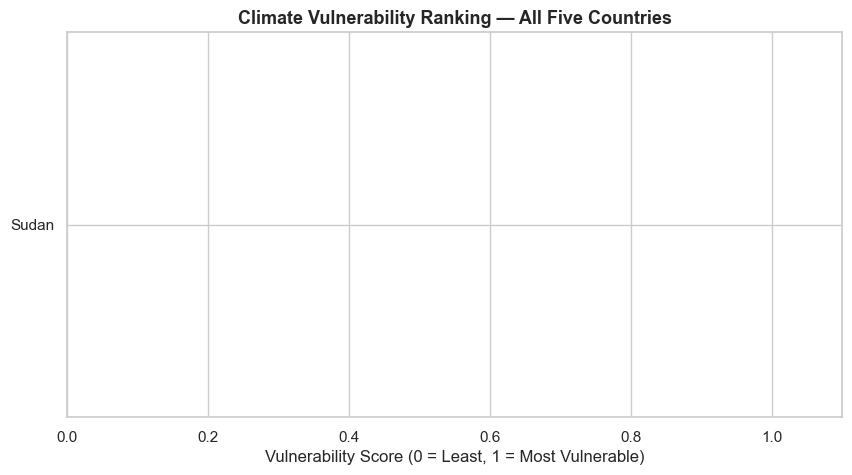

In [11]:
# Visualise vulnerability scores
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ranking['Country'][::-1], ranking['Vulnerability Score'][::-1],
               color=[COLORS[c] for c in ranking['Country'][::-1]],
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, ranking['Vulnerability Score'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Climate Vulnerability Ranking — All Five Countries', fontsize=13, fontweight='bold')
ax.set_xlabel('Vulnerability Score (0 = Least, 1 = Most Vulnerable)')
ax.set_xlim(0, 1.1)
plt.show()
